# Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.regularizers import l2
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# Tải lên dữ liệu

In [2]:
df = pd.read_csv('MSN.csv')

In [3]:
df.head()

,Ticker,Date/Time,Open,High,Low,Close,Volume,Open Interest
0,MSN,12/25/2017 9:15,73.1,73.1,73.1,73.1,4210,0
1,MSN,12/25/2017 9:16,73.0,73.0,73.0,73.0,5000,0
2,MSN,12/25/2017 9:18,73.5,73.5,73.5,73.5,210,0
3,MSN,12/25/2017 9:20,73.2,73.5,73.1,73.1,2050,0
4,MSN,12/25/2017 9:21,73.0,73.0,73.0,73.0,1380,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135354 entries, 0 to 135353
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Ticker         135354 non-null  object 
 1   Date/Time      135354 non-null  object 
 2   Open           135354 non-null  float64
 3   High           135354 non-null  float64
 4   Low            135354 non-null  float64
 5   Close          135354 non-null  float64
 6   Volume         135354 non-null  int64  
 7   Open Interest  135354 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 8.3+ MB


In [5]:
df.describe()

,Open,High,Low,Close,Volume,Open Interest
count,135354.000000,135354.000000,135354.000000,135354.000000,1.353540e+05,135354.0
mean,74.878809,74.931668,74.834625,74.880759,5.683578e+03,0.0
std,15.418074,15.426954,15.412677,15.418857,2.798513e+04,0.0
min,46.500000,46.500000,46.400000,46.400000,1.000000e+01,0.0
25%,57.900000,57.900000,57.800000,57.800000,5.000000e+02,0.0
50%,79.100000,79.200000,79.100000,79.100000,2.000000e+03,0.0
75%,86.000000,86.100000,86.000000,86.000000,5.560000e+03,0.0
max,117.800000,118.000000,117.700000,118.000000,3.300680e+06,0.0


# Làm sạch dữ liệu

In [6]:
df = df.drop('Ticker', axis=1)
df = df.drop('Open Interest', axis=1)

In [7]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M')

# Trực quan hóa dữ liệu

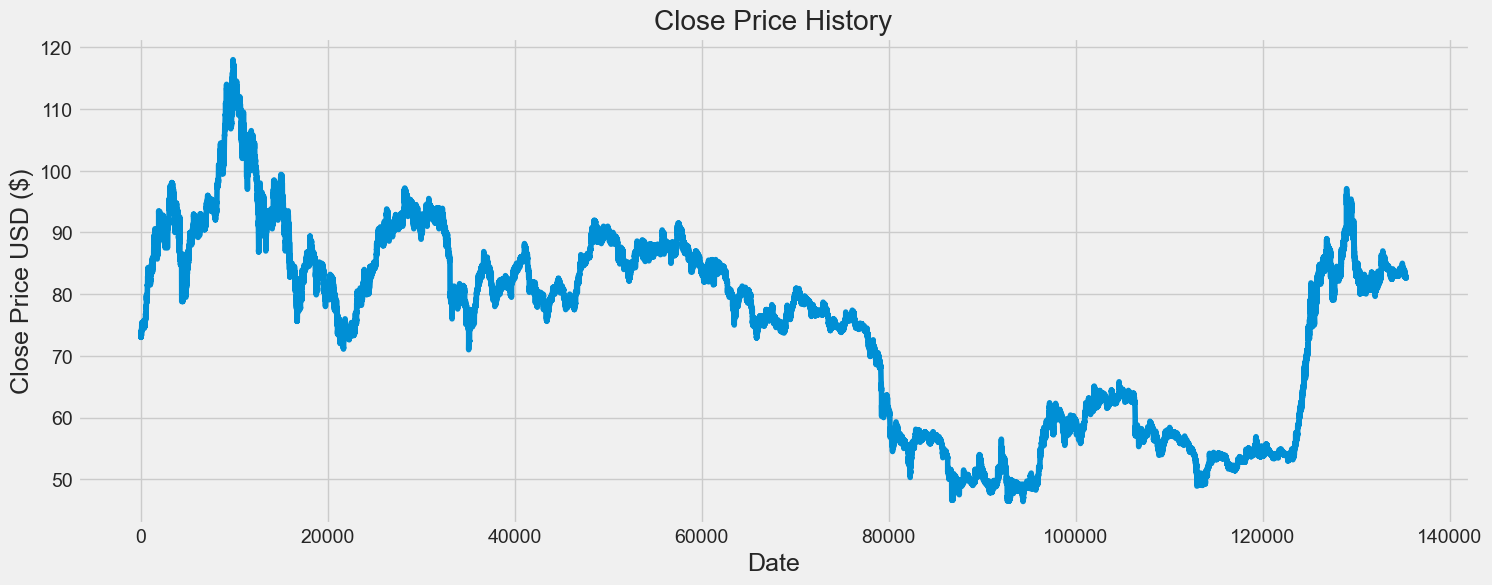

In [8]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

# Tiền xử lý dữ liệu

+ Lấy trung bình dữ liệu theo giờ để làm phẳng data và dễ dàng fill những data còn thiếu

In [9]:
df.set_index('Date/Time', inplace=True)

df = df.resample('H').mean()

In [10]:
df.describe()

,Open,High,Low,Close,Volume
count,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000
mean,76.221727,76.270549,76.180203,76.223766,5541.747354
std,14.853785,14.860773,14.849515,14.854484,7769.624807
min,46.506250,46.511607,46.500000,46.506250,70.000000
25%,61.516279,61.566102,61.436667,61.506977,2166.538462
50%,80.094737,80.150000,80.061905,80.092982,3532.954545
75%,86.723529,86.812281,86.711111,86.722222,6138.444444
max,117.020833,117.041667,117.008333,117.029167,125865.384615


In [11]:
df.isnull().sum()

Open      22505
High      22505
Low       22505
Close     22505
Volume    22505
dtype: int64

+ Lấp vào những data còn thiếu để có thể sử dụng các model time-series

In [12]:
df.interpolate(method='linear', inplace=True)  
df.ffill(inplace=True) 

In [13]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

+ Chia data thành tập dự đoán và tập dữ liệu dùng để dự đoán để dễ dàng inverse scale

In [14]:
df_X = df.reset_index()[['Open', 'High', 'Low', 'Close', 'Volume']]


In [15]:
df_X

,Open,High,Low,Close,Volume
0,73.191304,73.226087,73.178261,73.200000,2016.956522
1,73.583333,73.600000,73.583333,73.600000,1705.333333
2,73.800000,73.800000,73.783333,73.783333,2300.000000
3,73.775862,73.775862,73.753736,73.753736,1557.931034
4,73.751724,73.751724,73.724138,73.724138,815.862069
...,...,...,...,...,...
26233,83.350000,83.366667,83.329630,83.350000,1960.555556
26234,83.075862,83.086207,83.048276,83.058621,5269.310345
26235,82.917592,82.932934,82.891087,82.905582,4864.994155
26236,82.759322,82.779661,82.733898,82.752542,4460.677966


+ Data được dùng để dự đoán sẽ là data close sau time step sử dụng dữ liệu của các time-step trước đó

In [16]:
df_y = df.reset_index()['Close']

In [17]:
df_y

0        73.200000
1        73.600000
2        73.783333
3        73.753736
4        73.724138
           ...    
26233    83.350000
26234    83.058621
26235    82.905582
26236    82.752542
26237    82.750000
Name: Close, Length: 26238, dtype: float64

+ Mô hình được chọn là LSTM, vì nó có khả năng làm việc với dữ liệu trong theo thời gian rất tốt. Ngoài ra chúng ta còn có thể chọn ARIMA, tuy nhiên với dataset lớn và phức tạp như giá cổ phiếu, ARIMA sẽ không hoạt động tốt. Vì LSTM rất nhạy cảm với quy mô dữ liệu, chúng ta sẽ sử dụng MinMaxScaler.

+ Chúng ta phải chia thành 2 scaler ( một cho tập dữ liệu đầu vào và 1 tập dữ liệu đầu ra ) để có thể inverse scale mà không bị lỗi chiều dữ liệu

In [18]:
scaler1 = MinMaxScaler(feature_range=(0,4))   
df_X = scaler1.fit_transform(np.array(df_X).reshape(-1, 5))

In [19]:
scaler2 = MinMaxScaler(feature_range=(0,1))   
df_y = scaler2.fit_transform(np.array(df_y).reshape(-1, 1))

In [20]:
df_X

array([[1.51373251, 1.51506918, 1.51348129, 1.51404685, 0.06190868],
       [1.53597069, 1.53627506, 1.53646141, 1.53673451, 0.05199979],
       [1.54826129, 1.54761774, 1.54780759, 1.54713302, 0.0709088 ],
       ...,
       [2.06546449, 2.06557755, 2.0644985 , 2.0645392 , 0.15246964],
       [2.05648649, 2.05688492, 2.05558104, 2.05585895, 0.13961332],
       [2.05616028, 2.05621548, 2.05568406, 2.05571475, 0.05742886]])

In [21]:
df_y

array([[0.37851171],
       [0.38418363],
       [0.38678326],
       ...,
       [0.5161348 ],
       [0.51396474],
       [0.51392869]])

In [22]:
data = np.concatenate([df_X, df_y], axis=1)

In [23]:
data

array([[1.51373251, 1.51506918, 1.51348129, 1.51404685, 0.06190868,
        0.37851171],
       [1.53597069, 1.53627506, 1.53646141, 1.53673451, 0.05199979,
        0.38418363],
       [1.54826129, 1.54761774, 1.54780759, 1.54713302, 0.0709088 ,
        0.38678326],
       ...,
       [2.06546449, 2.06557755, 2.0644985 , 2.0645392 , 0.15246964,
        0.5161348 ],
       [2.05648649, 2.05688492, 2.05558104, 2.05585895, 0.13961332,
        0.51396474],
       [2.05616028, 2.05621548, 2.05568406, 2.05571475, 0.05742886,
        0.51392869]])

+ Tạo dataset để train time-series model

In [24]:
training_size = int(len(data)*0.75)
test_size = len(data) - training_size
train_data_X = df_X[:training_size, :]
test_data_X = df_X[training_size:, :]
train_data_y = df_y[:training_size, :]
test_data_y = df_y[training_size:, :]

In [25]:
train_data_X.shape, test_data_X.shape

((19678, 5), (6560, 5))

In [26]:
def create_dataset(df_x, df_y, time_step=1):
    dataX, dataY = [], []
    for i in range(len(df_y) - time_step - 1):
        a = df_x[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(df_y[i + time_step, -1])
    return np.array(dataX), np.array(dataY)

In [27]:
time_step = 100,
X_train, y_train = create_dataset(train_data_X, train_data_y, time_step[0])
X_test, y_test = create_dataset(test_data_X, test_data_y, time_step[0])

In [28]:
y_train = y_train.reshape(-1,1 )
y_test = y_test.reshape(-1,1 )

In [29]:
X_train 

array([[[1.51373251, 1.51506918, 1.51348129, 1.51404685, 0.06190868],
        [1.53597069, 1.53627506, 1.53646141, 1.53673451, 0.05199979],
        [1.54826129, 1.54761774, 1.54780759, 1.54713302, 0.0709088 ],
        ...,
        [1.68513962, 1.6861377 , 1.68564356, 1.68661233, 0.14134836],
        [1.68619416, 1.68722555, 1.6866982 , 1.6877003 , 0.14060384],
        [1.6872487 , 1.68831341, 1.68775283, 1.68878826, 0.13985932]],

       [[1.53597069, 1.53627506, 1.53646141, 1.53673451, 0.05199979],
        [1.54826129, 1.54761774, 1.54780759, 1.54713302, 0.0709088 ],
        [1.54689205, 1.5462488 , 1.54612848, 1.54545427, 0.04731274],
        ...,
        [1.68619416, 1.68722555, 1.6866982 , 1.6877003 , 0.14060384],
        [1.6872487 , 1.68831341, 1.68775283, 1.68878826, 0.13985932],
        [1.68830325, 1.68940126, 1.68880747, 1.68987622, 0.1391148 ]],

       [[1.54826129, 1.54761774, 1.54780759, 1.54713302, 0.0709088 ],
        [1.54689205, 1.5462488 , 1.54612848, 1.54545427, 0.0

In [30]:
y_train

array([[0.42246906],
       [0.42791409],
       [0.42802766],
       ...,
       [0.02596614],
       [0.02635604],
       [0.02674594]])

In [31]:
X_test.shape, y_test.shape

((6459, 100, 5), (6459, 1))

In [32]:
print(X_train.shape), print(y_train.shape)
print(X_test.shape), print(y_test.shape)

(19577, 100, 5)
(19577, 1)
(6459, 100, 5)
(6459, 1)


(None, None)

# Tạo model Stacked LSTM

30 30 30 0.3 0.01 100 epochs

In [33]:
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(40, return_sequences=True, input_shape=(time_step[0], 5)),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.LSTM(40, return_sequences=True),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.LSTM(40),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')


c:\Users\phana\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

batch_size = 64
train_dataset = train_dataset.batch(batch_size).repeat()  
test_dataset = test_dataset.batch(batch_size)

+ Chọn số vòng lặp = 100 vì sau khi đánh giá model ta thấy từ sau vòng lặp 100 lỗi của mô hình sẽ tăng dần.

In [35]:
history = ( 
    model.fit(train_dataset, 
          validation_data=(X_test,y_test), 
          epochs=100, 
          steps_per_epoch=len(X_train) // batch_size, 
          verbose=1)
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 30s 82ms/step - loss: 0.0165 - val_loss: 0.0288
Epoch 2/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - loss: 0.0222 - val_loss: 0.0417
Epoch 3/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step - loss: 0.0284 - val_loss: 0.0381
Epoch 4/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 27s 88ms/step - loss: 0.0255 - val_loss: 0.0171
Epoch 5/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - loss: 0.0218 - val_loss: 0.0121
Epoch 6/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - loss: 0.0188 - val_loss: 0.0099
Epoch 7/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - loss: 0.0166 - val_loss: 0.0086
Epoch 8/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - loss: 0.0154 - val_loss: 0.0060
Epoch 9/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - loss: 0.0139 - val_loss: 0.0049
Epoch 10/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - loss: 0.0126 - val_loss: 0.0044
Epoch 11/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - loss: 0.0118 - val_loss: 0.0056
Epoch 12/100
305/30

# Đánh giá model

+ Chúng ta cần xét loss của model qua mỗi epoch để có thể dừng train sớm, giảm thiểu tối đa loss

In [36]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

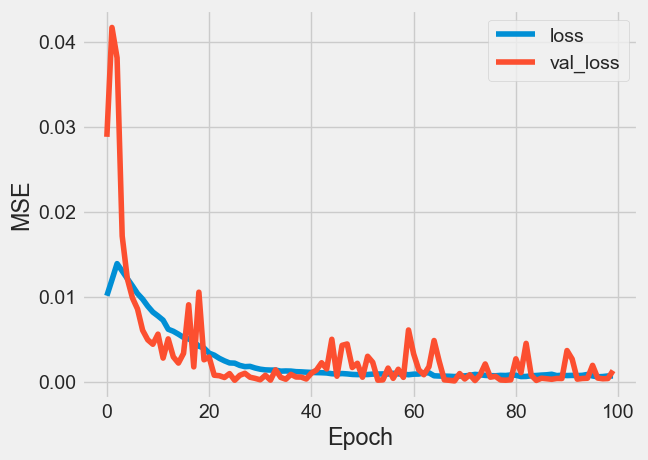

In [37]:
plot_loss(history)

+ Tiếp theo chúng ta cần đánh giá độ chính xác của dự đoán

In [38]:
predictions_scaled = model.predict(X_test)
predictions_scaled = predictions_scaled.reshape(-1,1)

predictions_train = model.predict(X_train) 
predictions_train = predictions_train.reshape(-1,1)

202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
612/612 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step


In [39]:
predictions = scaler2.inverse_transform(predictions_scaled)
predictions_train = scaler2.inverse_transform(predictions_train)
y_test = scaler2.inverse_transform(y_test)
y_train = scaler2.inverse_transform(y_train)

In [40]:
column_names_pred = ['Close_predict']
df_predictions = pd.DataFrame(predictions, columns=column_names_pred)

df_test = pd.DataFrame(y_test)

In [41]:
df_predictions

,Close_predict
0,49.336498
1,49.322098
2,49.307827
3,49.293667
4,49.279583
...,...
6454,83.300842
6455,83.296913
6456,83.304901
6457,83.245270


In [42]:
df_test

,0
0,49.730094
1,49.709701
2,49.689309
3,49.668917
4,49.648524
...,...
6454,83.430233
6455,83.350000
6456,83.058621
6457,82.905582


In [43]:
concatenated = np.concatenate([df_predictions, df_test], axis=1)
column_names_concat = ['Close_predict', 'Close_test']
df_concatenated = pd.DataFrame(concatenated, columns = column_names_concat)

df_test.reset_index(drop=True, inplace=True)

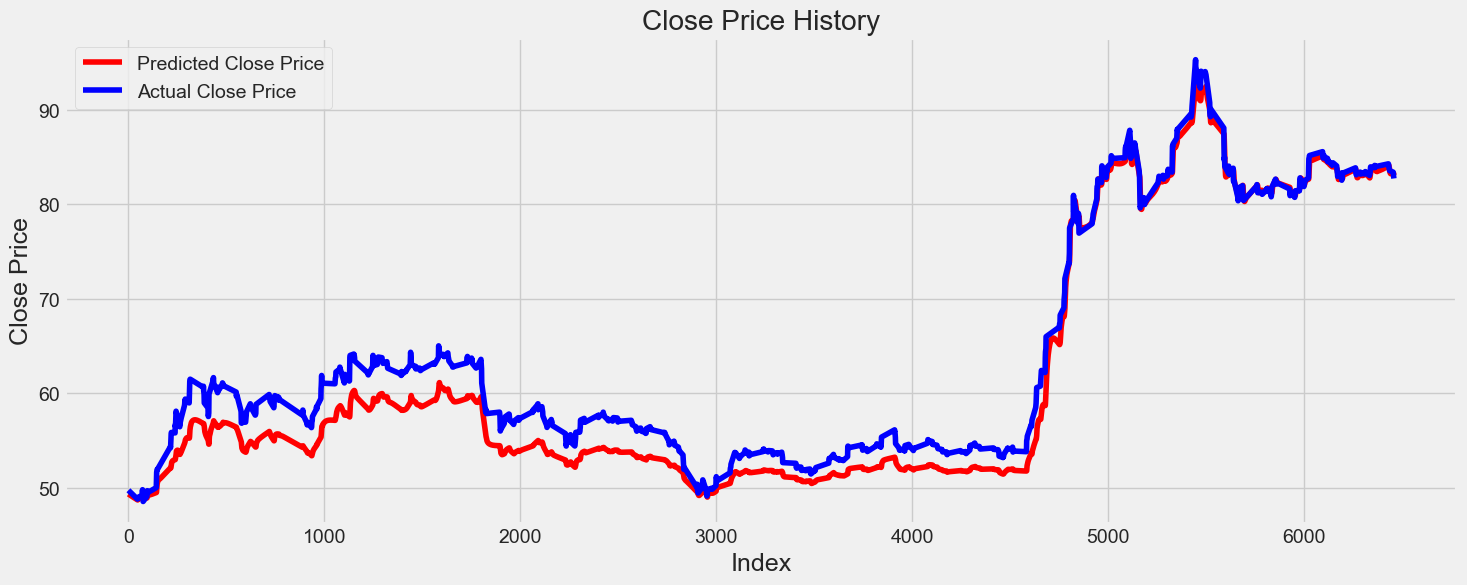

In [44]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df_predictions['Close_predict'], color='red', label='Predicted Close Price')
plt.plot(df_test, color='blue', label='Actual Close Price')
plt.legend()
plt.xlabel('Index', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()

+ Đánh giá độ hiệu quả của mô hình bằng các metrics

In [45]:
mae_train = mean_absolute_error(y_train, predictions_train)
rmse_train = mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)

print("Train Mean Absolute Error:", mae_train)
print("Train Mean Squared Error:", rmse_train)
print("Train R-squared:", r2_train)

Train Mean Absolute Error: 0.9247278859982234
Train Mean Squared Error: 2.4846348454828537
Train R-squared: 0.9854871012821554


In [46]:
mae_test = mean_absolute_error(y_test, predictions)
rmse_test = mean_squared_error(y_test, predictions)
r2_test = r2_score(y_test, predictions)

print("Test Mean Absolute Error:", mae_test)
print("Test Mean Squared Error:", rmse_test)
print("Test R-squared:", r2_test)

Test Mean Absolute Error: 2.13555815241787
Test Mean Squared Error: 6.470905495004418
Test R-squared: 0.9581172244462878


# Dự đoán

In [47]:
len(test_data_X)

6560

In [48]:
demo_test = test_data_X

In [49]:
x_input = demo_test[-(time_step[0]):]

In [50]:
x_input

array([[2.13355056, 2.1350066 , 2.1330812 , 2.13451386, 0.22057362],
       [2.12852524, 2.12963737, 2.12798503, 2.12902563, 0.15820697],
       [2.12349992, 2.12426813, 2.12288887, 2.1235374 , 0.09584033],
       [2.1255841 , 2.12737512, 2.12484607, 2.12679665, 0.69973335],
       [2.12586145, 2.12762688, 2.12512774, 2.12705212, 0.69073636],
       [2.1261388 , 2.12787863, 2.12540942, 2.12730759, 0.68173937],
       [2.12641615, 2.12813039, 2.12569109, 2.12756306, 0.67274239],
       [2.12669349, 2.12838215, 2.12597276, 2.12781853, 0.6637454 ],
       [2.12697084, 2.1286339 , 2.12625444, 2.128074  , 0.65474841],
       [2.12724819, 2.12888566, 2.12653611, 2.12832946, 0.64575142],
       [2.12752554, 2.12913742, 2.12681779, 2.12858493, 0.63675444],
       [2.12780288, 2.12938917, 2.12709946, 2.1288404 , 0.62775745],
       [2.12808023, 2.12964093, 2.12738114, 2.12909587, 0.61876046],
       [2.12835758, 2.12989268, 2.12766281, 2.12935134, 0.60976348],
       [2.12863493, 2.13014444, 2.

In [51]:
x_input = x_input.reshape(time_step[0], 5)

In [52]:
x_input.shape

(100, 5)

+ Tạo ra một dữ liệu test tạm thời

In [53]:
temp_input = list(x_input) 

In [54]:
temp_input_lists = [arr.tolist() for arr in temp_input]

In [55]:
temp_input 

[array([2.13355056, 2.1350066 , 2.1330812 , 2.13451386, 0.22057362]),
 array([2.12852524, 2.12963737, 2.12798503, 2.12902563, 0.15820697]),
 array([2.12349992, 2.12426813, 2.12288887, 2.1235374 , 0.09584033]),
 array([2.1255841 , 2.12737512, 2.12484607, 2.12679665, 0.69973335]),
 array([2.12586145, 2.12762688, 2.12512774, 2.12705212, 0.69073636]),
 array([2.1261388 , 2.12787863, 2.12540942, 2.12730759, 0.68173937]),
 array([2.12641615, 2.12813039, 2.12569109, 2.12756306, 0.67274239]),
 array([2.12669349, 2.12838215, 2.12597276, 2.12781853, 0.6637454 ]),
 array([2.12697084, 2.1286339 , 2.12625444, 2.128074  , 0.65474841]),
 array([2.12724819, 2.12888566, 2.12653611, 2.12832946, 0.64575142]),
 array([2.12752554, 2.12913742, 2.12681779, 2.12858493, 0.63675444]),
 array([2.12780288, 2.12938917, 2.12709946, 2.1288404 , 0.62775745]),
 array([2.12808023, 2.12964093, 2.12738114, 2.12909587, 0.61876046]),
 array([2.12835758, 2.12989268, 2.12766281, 2.12935134, 0.60976348]),
 array([2.12863493, 

In [56]:
temp_input = np.array(temp_input)
temp_input.shape

(100, 5)

+ Đưa ra dự đoán cho 24 giờ tiếp theo

In [57]:
def predict_next_24_steps(model, initial_input, n_steps=24):
    predictions = []
    current_input = initial_input.copy()  

    for i in range(n_steps-1):
        if len(current_input.shape) == 2:
            current_input_reshaped = current_input.reshape(1, current_input.shape[0], current_input.shape[1])
        else:
            raise ValueError("current_input must be a 2D array with shape (time_steps, features)")

        next_step_prediction = model.predict(current_input_reshaped)[0, 0]  
        
        predictions.append(next_step_prediction)
        
        current_input = np.append(current_input[1:], [[next_step_prediction] + [0]*(current_input.shape[1]-1)], axis=0)

    return predictions

In [58]:
stocks = predict_next_24_steps(model, temp_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [59]:
stocks

[0.5147809,
 0.49133497,
 0.46080655,
 0.4203719,
 0.36824906,
 0.30628118,
 0.2411827,
 0.17625967,
 0.11738813,
 0.070182264,
 0.036055207,
 0.01410985,
 0.0016317368,
 -0.0043855906,
 -0.006203085,
 -0.005518079,
 -0.0036838353,
 -0.0016257763,
 0.00019583106,
 0.0016745031,
 0.0028845668,
 0.003930092,
 0.004864484]

In [60]:
print('Biến động cổ phiếu trong 24h tới:')
for i in stocks:
    a = scaler2.inverse_transform(i.reshape(-1, 1))
    print(a - df['Close'][-1])

Biến động cổ phiếu trong 24h tới:
[[0.06009674]]
[[-1.5933685]]
[[-3.7463226]]
[[-6.5979004]]
[[-10.27375]]
[[-14.643906]]
[[-19.23484]]
[[-23.813404]]
[[-27.965199]]
[[-31.294292]]
[[-33.701035]]
[[-35.248684]]
[[-36.128677]]
[[-36.553036]]
[[-36.68121]]
[[-36.632904]]
[[-36.503544]]
[[-36.358406]]
[[-36.22994]]
[[-36.12566]]
[[-36.04032]]
[[-35.96659]]
[[-35.900692]]
